### Inputs parameters of the main processing function

First, here is a basic use of the function with a .parquet file:

In [1]:
from BatteryDataAnalysis import process_file

file_path = 'C:/Examples/example_data.parquet'
df, result_dict = process_file(file_path)

File : example_data.parquet
Length : 72984
Preprocessing Time : 1s
Find Test Time : 0s
NA
Test : NA ; Length : 72967
dQ/dV Time : 1s
Total Time : 4s


The file extensions allowed are: .csv, .txt, .parquet, .xlsx and .xls.

But you can also directly read a dataframe:

In [2]:
import pyarrow.parquet as pq

df_input = pq.read_table(file_path).to_pandas()

df, result_dict = process_file(df_input, input='dataframe')

Length : 72984
Preprocessing Time : 1s
Find Test Time : 0s
NA
Test : NA ; Length : 72967
dQ/dV Time : 1s
Total Time : 4s


Then, if the file's column names are unusual, or if the function return the error: 'Error processing file: Column 'SysTime' not found in the DataFrame.':
You have to create a column_names dictionary and put the right column names for SysTime, Voltage and/or Current.  

SysTime corresponds to either System Time as a timestamp or a regular Time column.

In [3]:
column_names = {
    "TestTime/Sec": "SysTime",
    "Current/mA": "Current",
    "Voltage/V": "Voltage"}

df, result_dict = process_file(file_path, column_names=column_names)

File : example_data.parquet
Length : 72984
Preprocessing Time : 1s
Find Test Time : 0s
NA
Test : NA ; Length : 72960
dQ/dV Time : 1s
Total Time : 4s


If you want to debug or to manage your data, you can add a debug function that will manipulate the dataframe before preprocessing it.  

For example, you can choose to remove the data after 600000 seconds:

In [4]:
def debug_func(df):
    df = df[df['TestTime/Sec'] < 600000]
    return df

column_names = {
    "TestTime/Sec": "SysTime",
    "Current/mA": "Current",
    "Voltage/V": "Voltage"}

df, result_dict = process_file(file_path, column_names=column_names, debug_func=debug_func)

File : example_data.parquet
Length : 58280
Preprocessing Time : 1s
Find Test Time : 0s
NA
Test : NA ; Length : 58258
dQ/dV Time : 2s
Total Time : 5s


By default, the function saves the result plots in the folder: 'C:/path_to_your_data/file_name/' as HTML files.  

You can choose not to save your result plots and instead to plot it directly on your browser.

File : example_data.parquet
Length : 72984
Preprocessing Time : 1s
Find Test Time : 0s


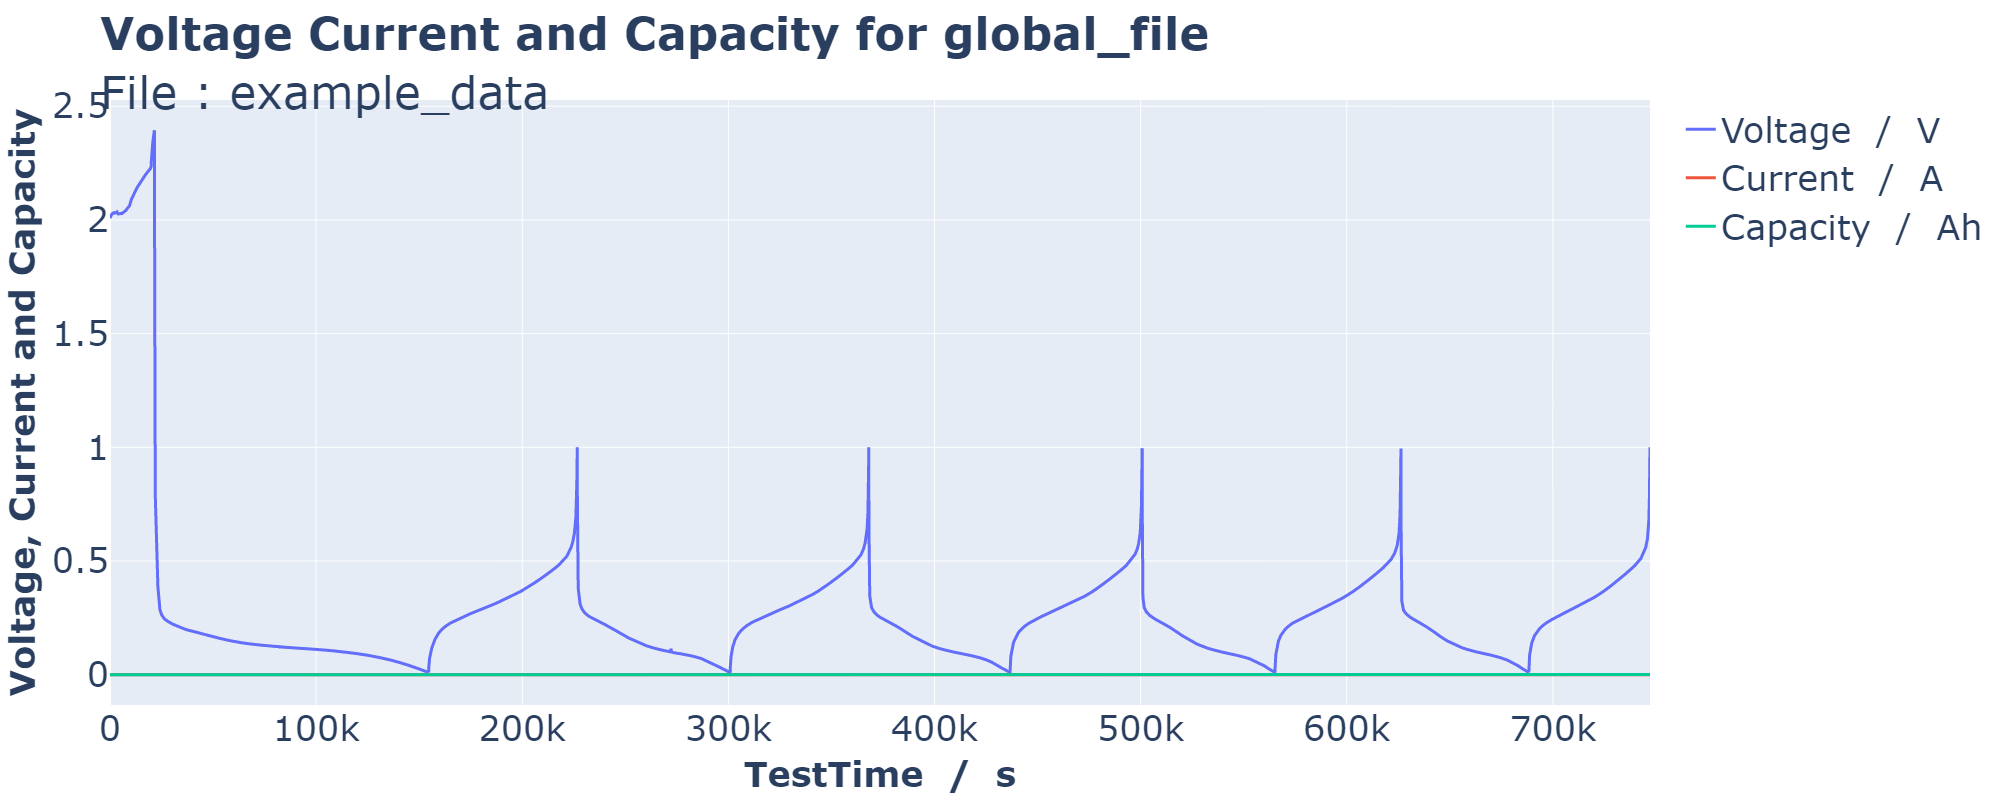

NA
Test : NA ; Length : 72967


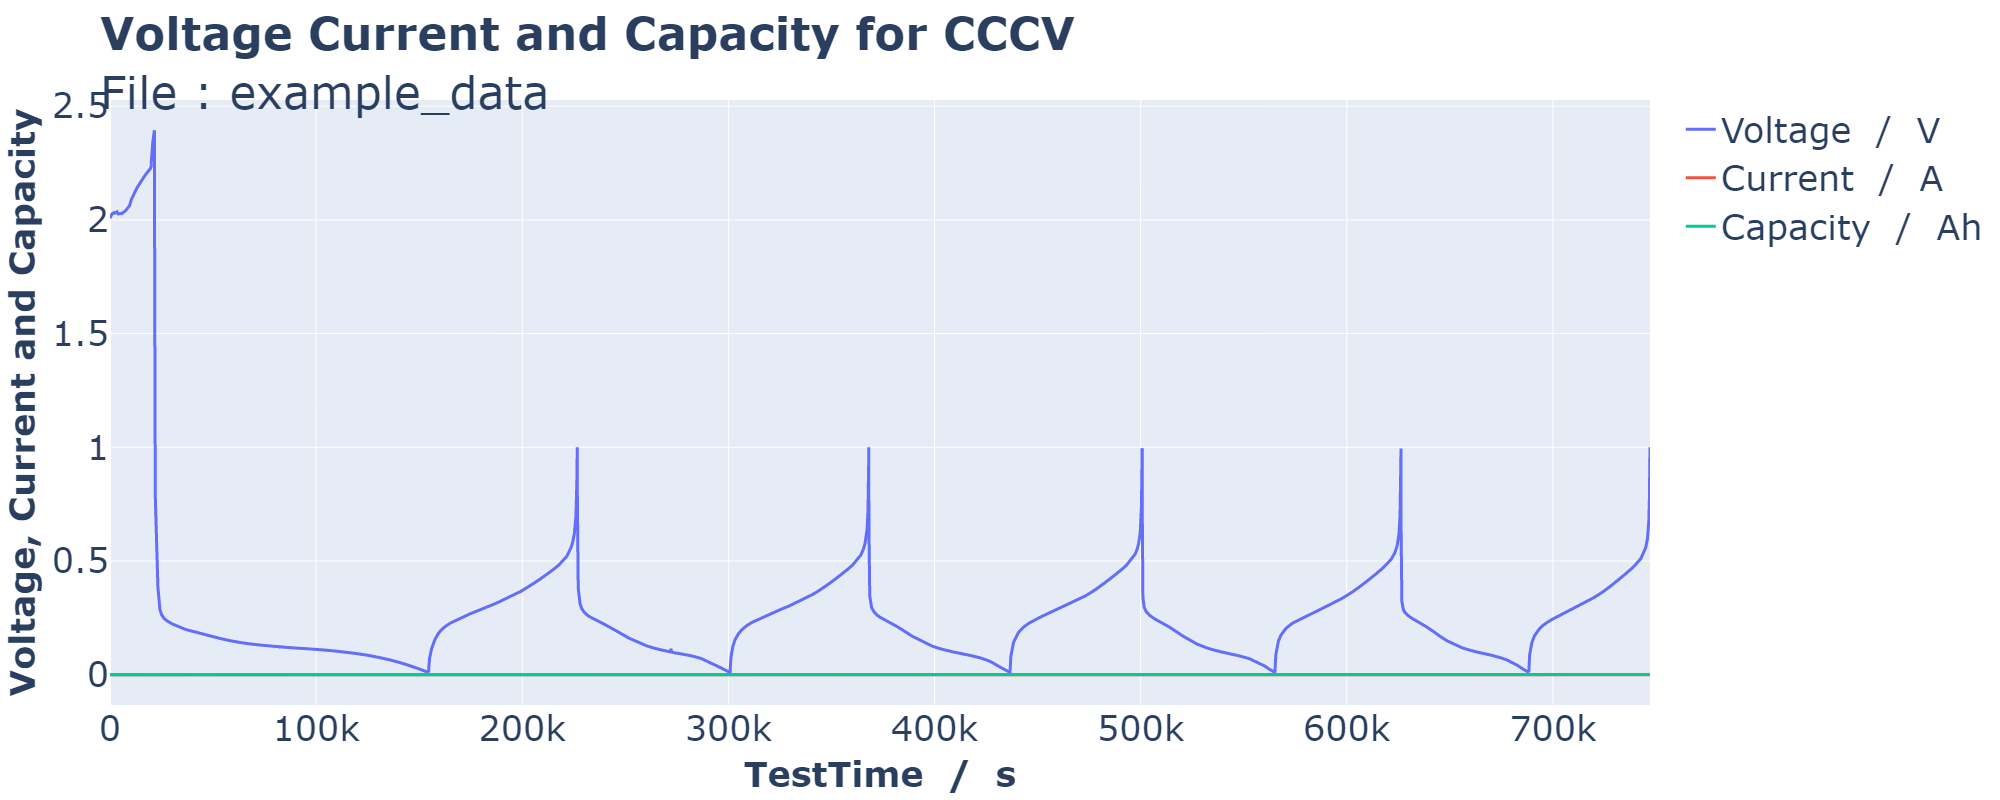

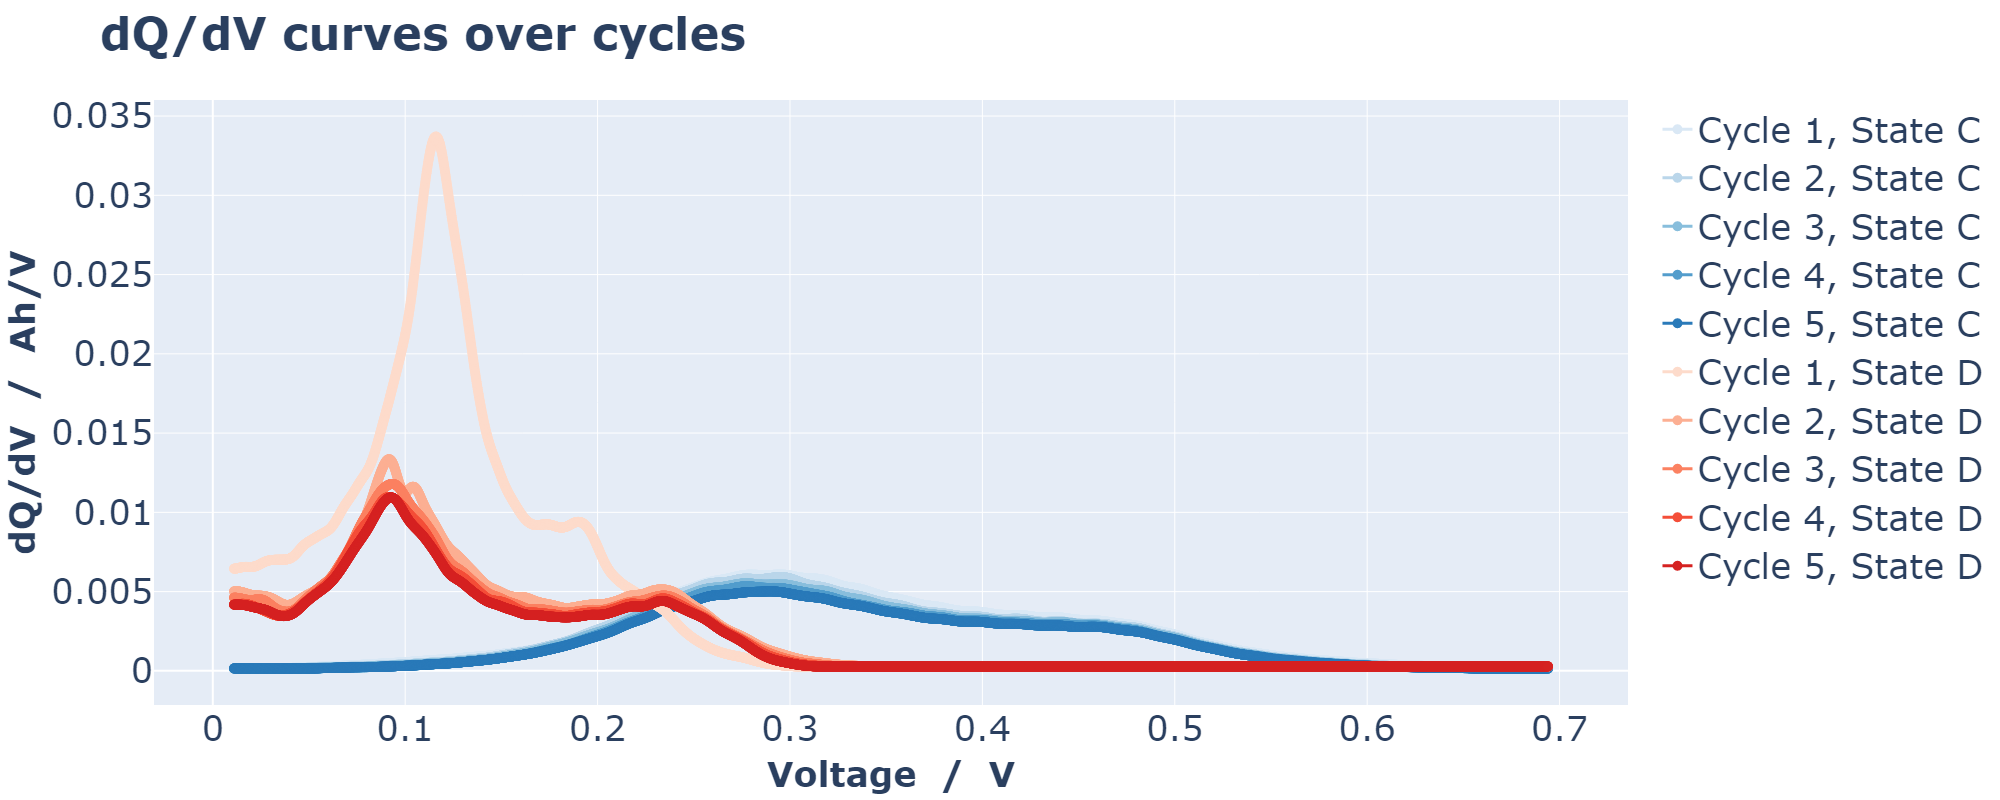

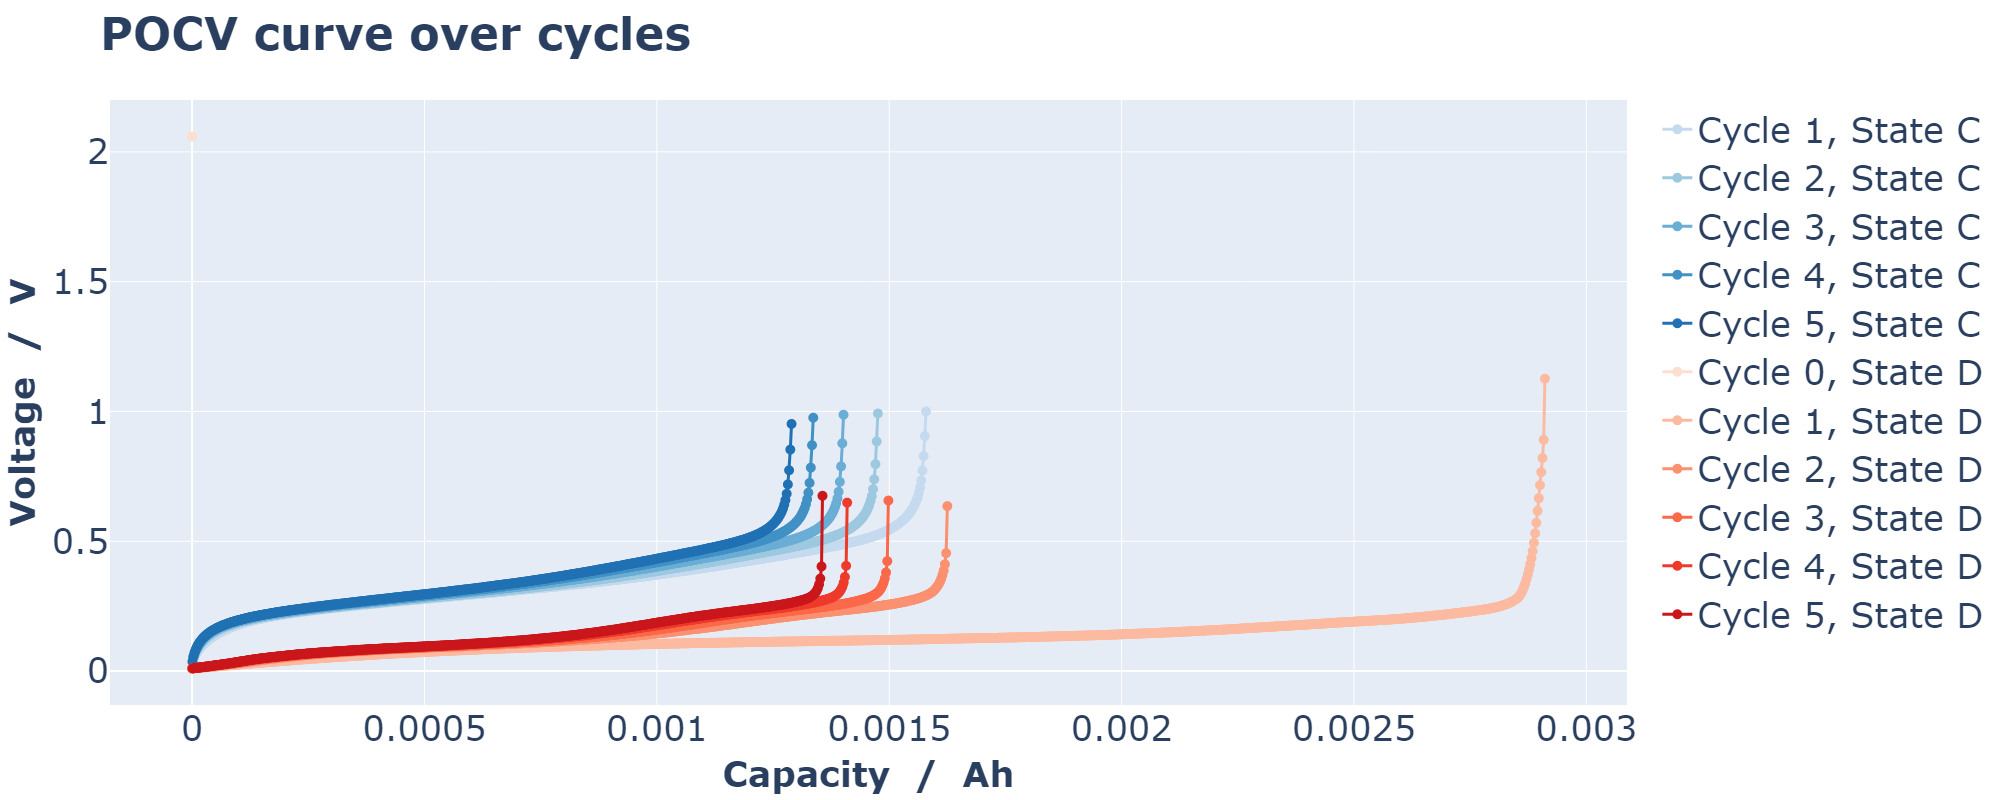

dQ/dV Time : 10s
Total Time : 15s


In [ ]:
df, result_dict = process_file(file_path, plot=True, save=False)

You can also choose to analyse specific cycling number of your data:

File : example_data.parquet
Length : 72984
Preprocessing Time : 1s
Find Test Time : 0s


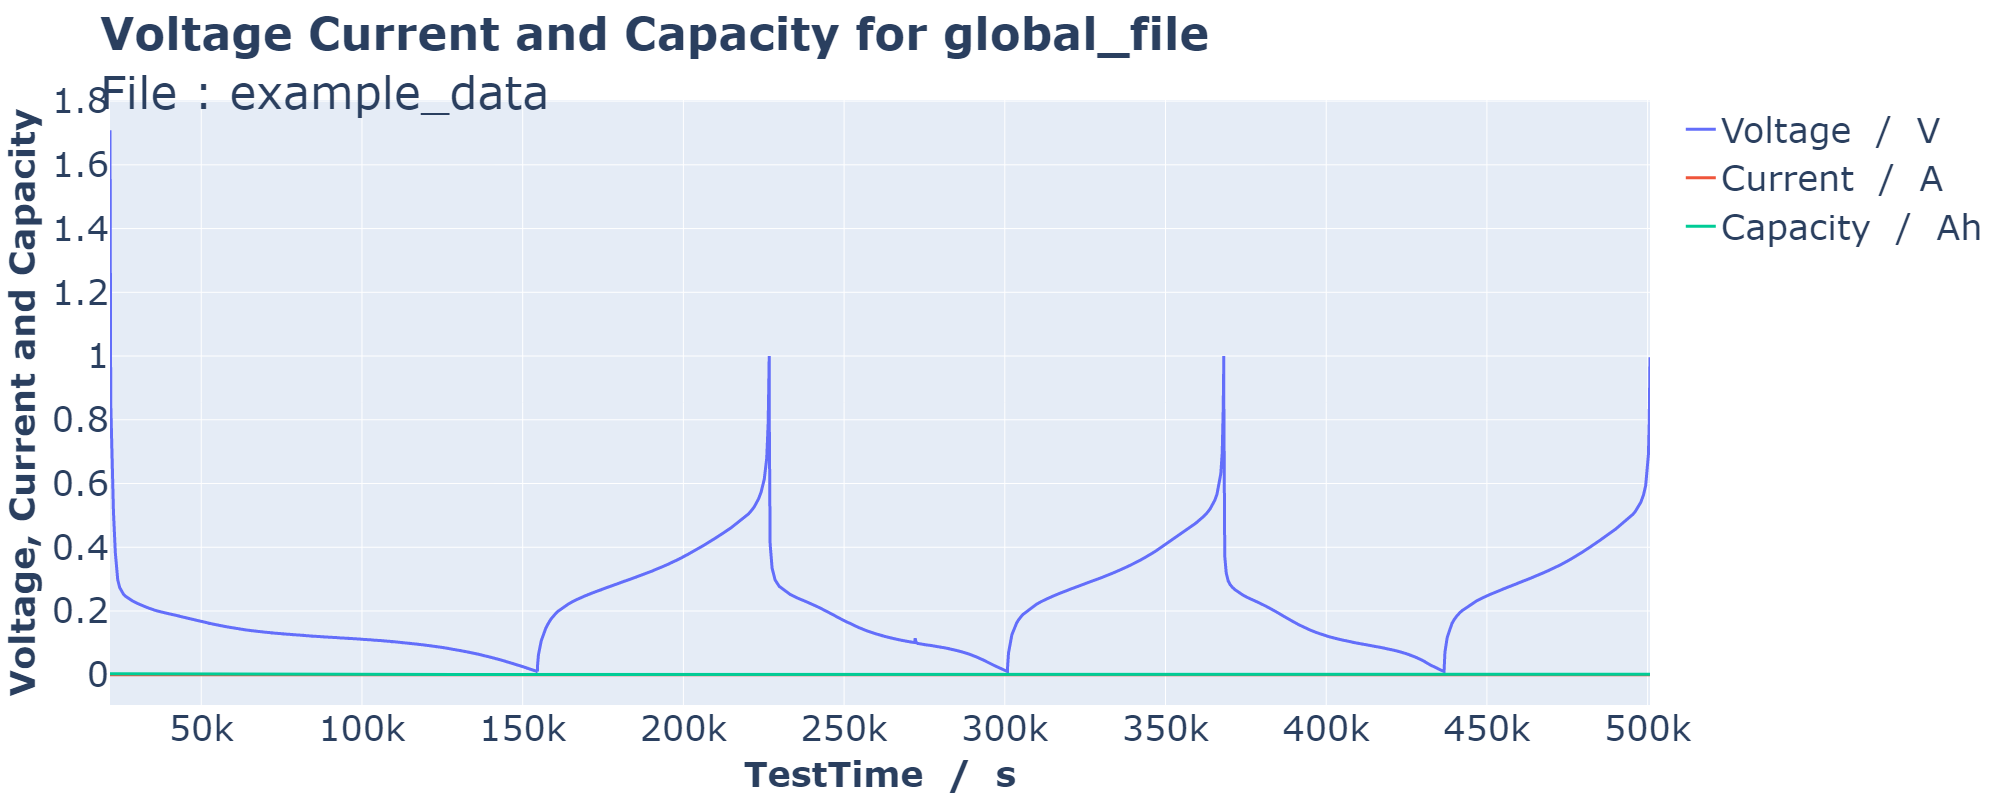

NA
Test : NA ; Length : 47954


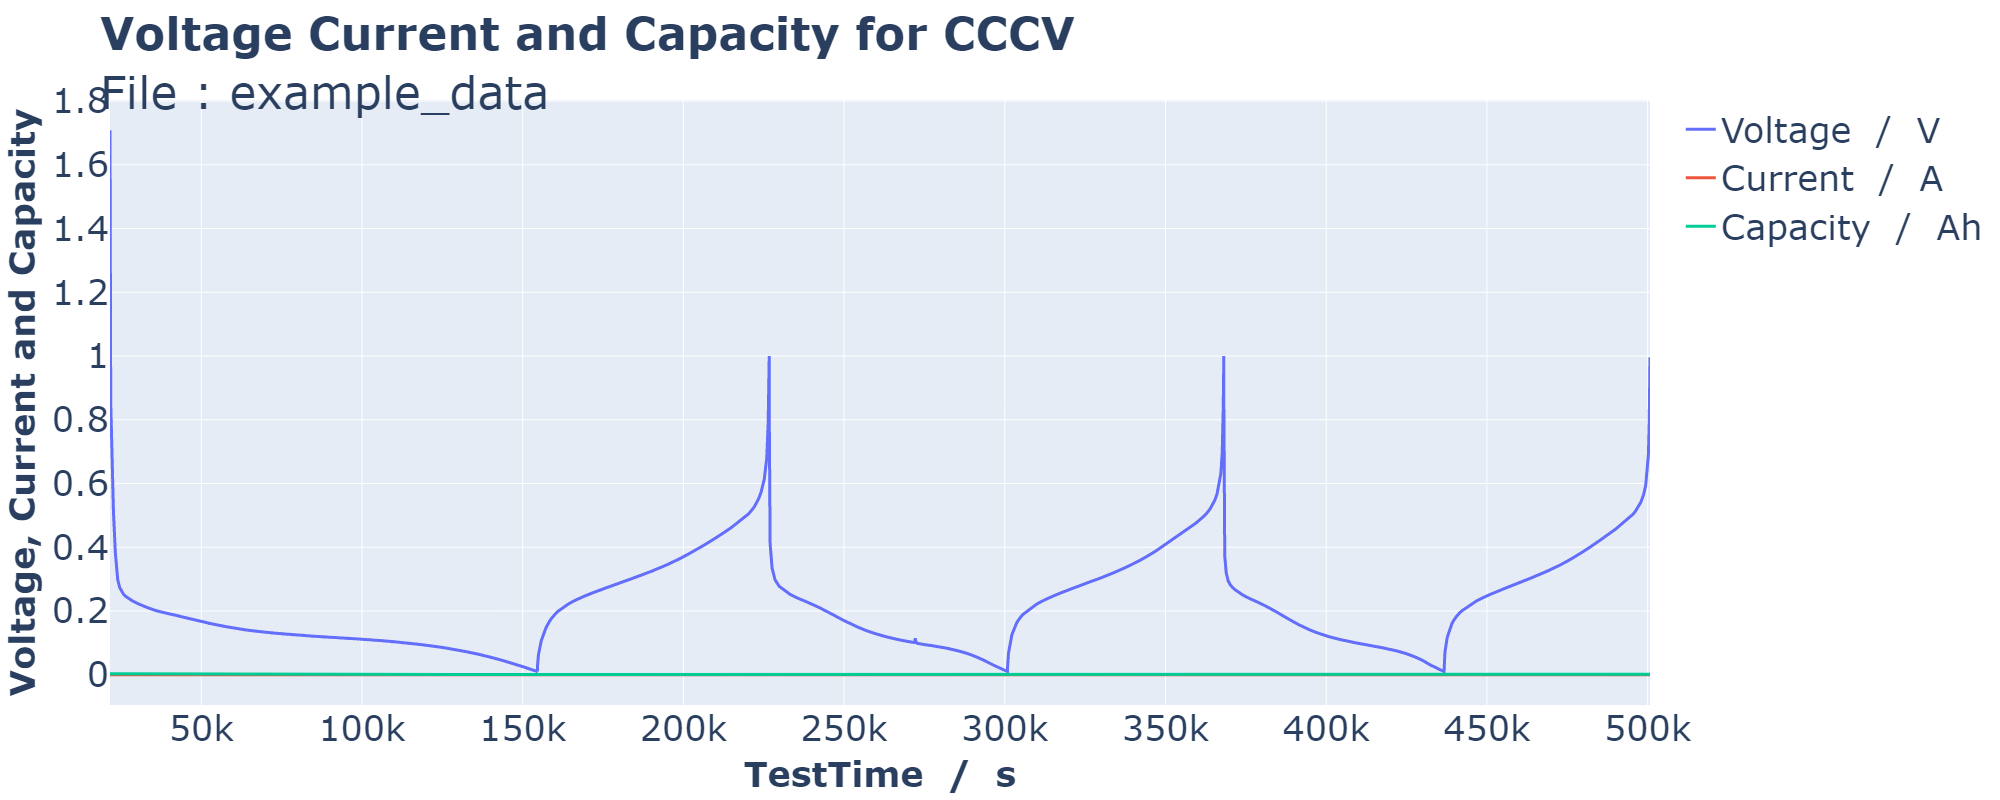

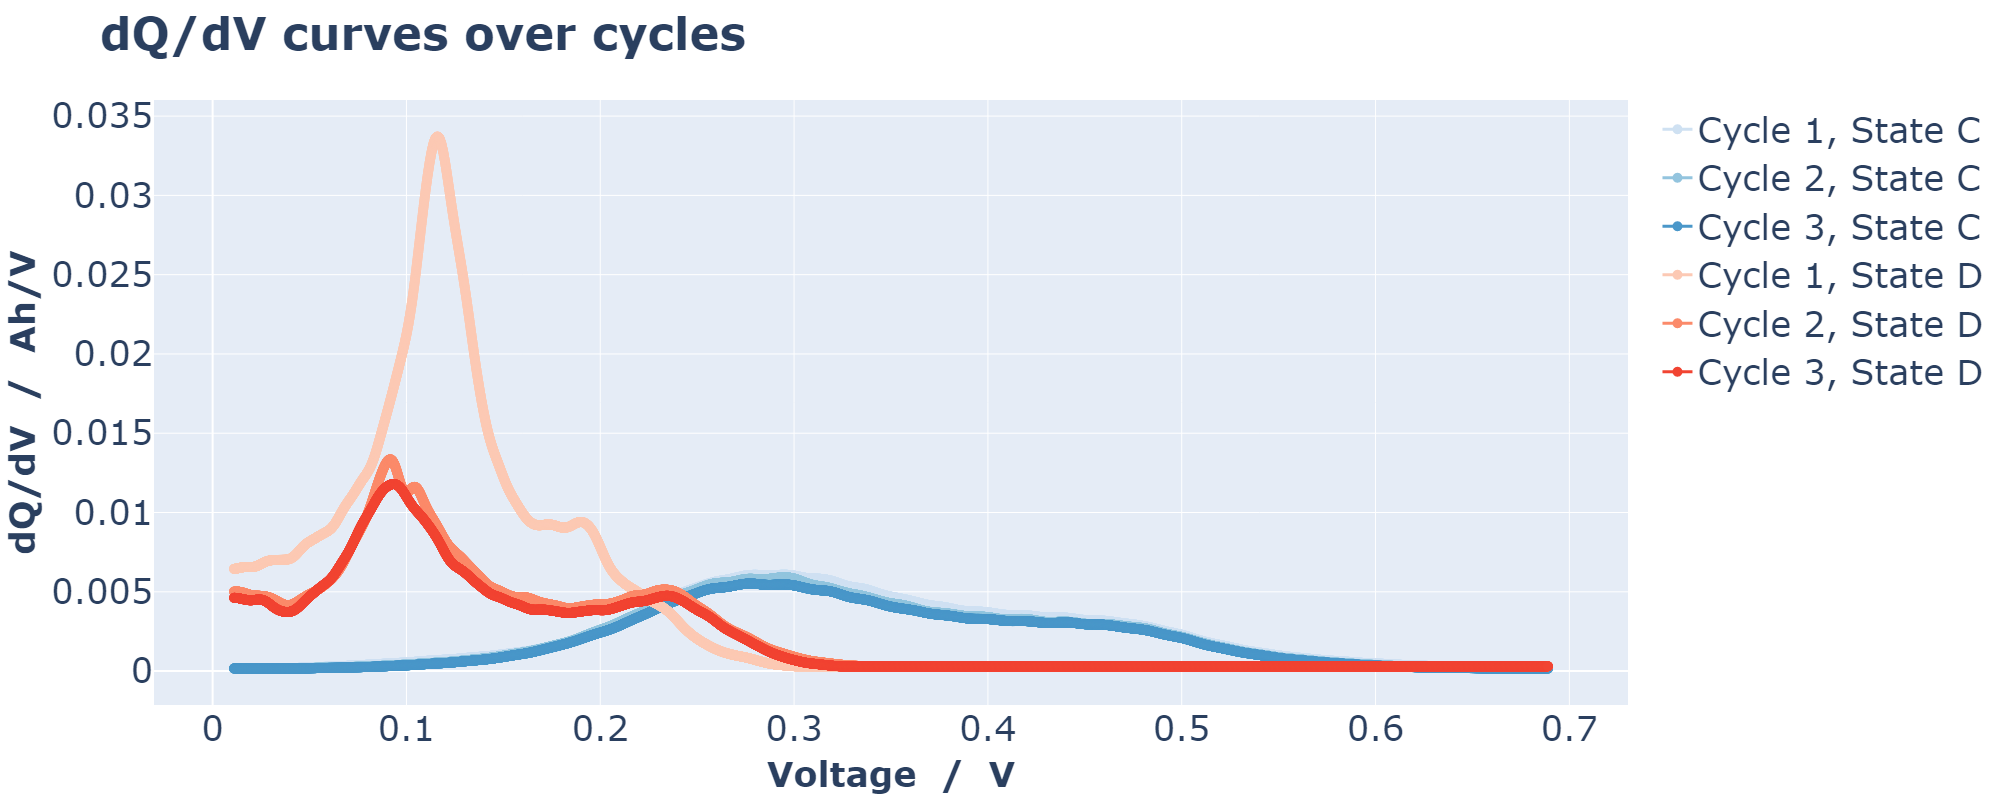

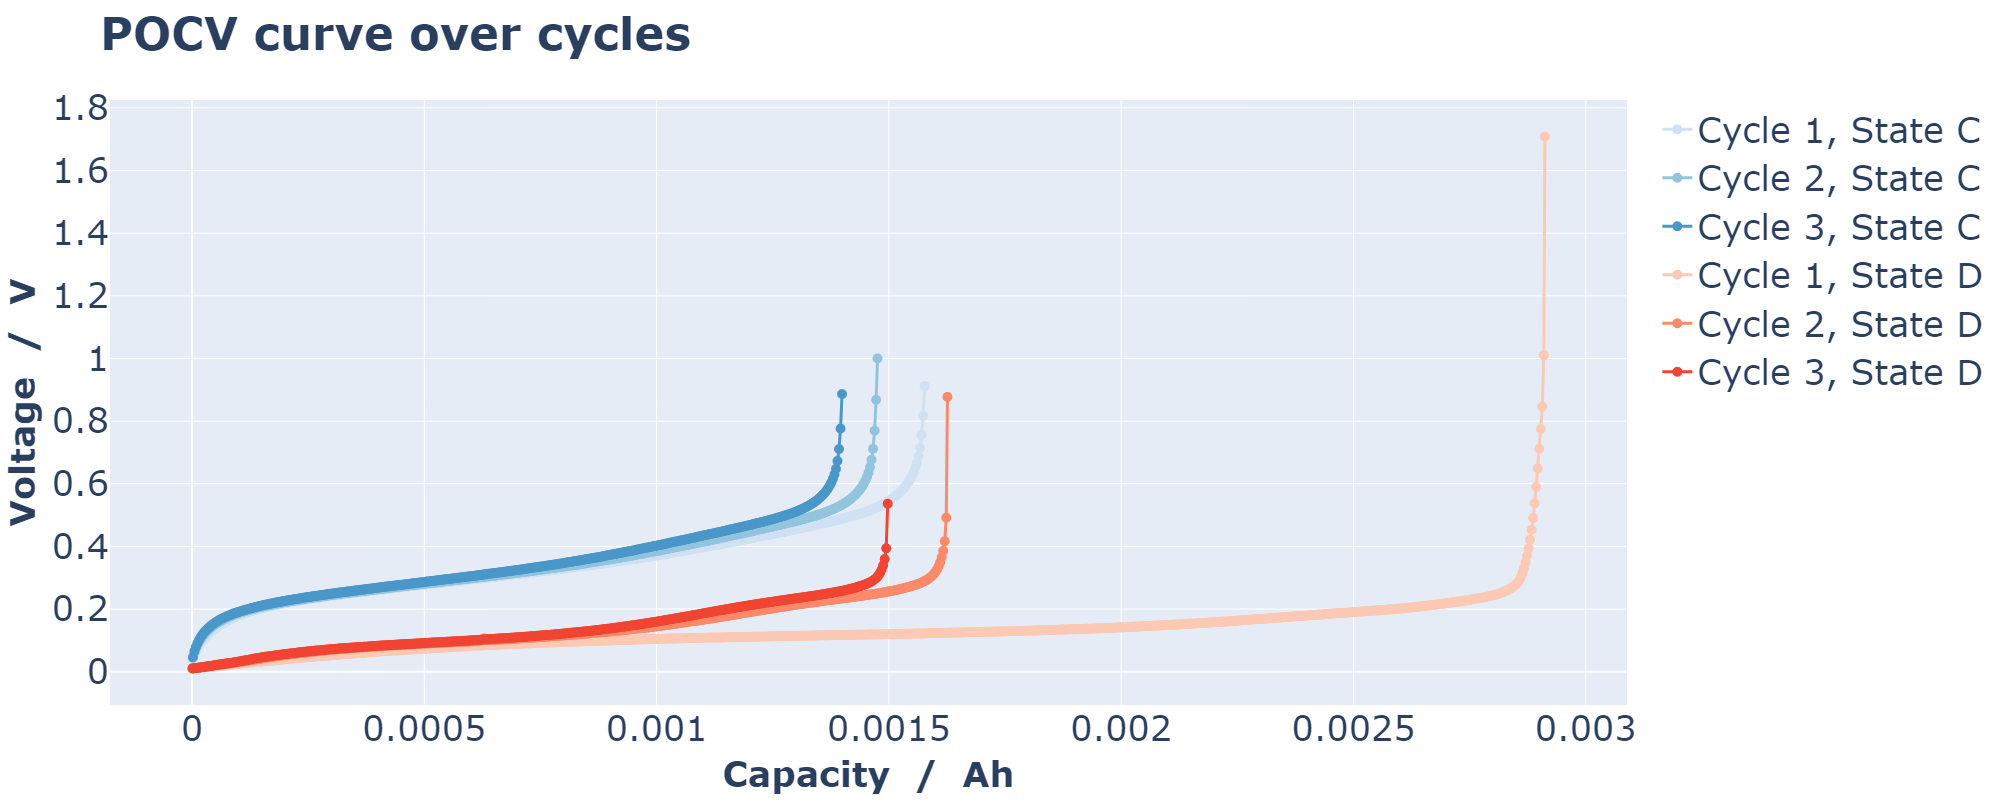

dQ/dV Time : 13s
Total Time : 17s


In [ ]:
df, result_dict = process_file(file_path, cycle=[1,2,3], plot=True, save=False)